In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


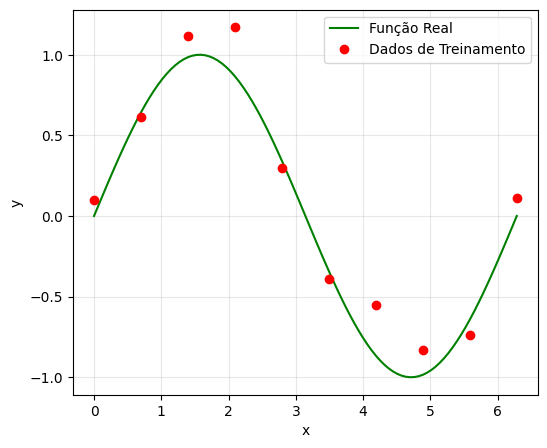

In [29]:
# Dados: 
np.random.seed(42)
N = 10

# Dados de treinamento (Ruidosos)
x = np.linspace(0, 2*np.pi, N)
y = np.sin(x) + np.random.normal(0, 0.2, N)

# Dados para visualização da curva real (Suave)
x_v = np.linspace(0, 2*np.pi, 100)
y_v = np.sin(x_v)

plt.figure(figsize=(6,5))
plt.plot(x_v, y_v, label='Função Real', color='green')
plt.plot(x,y, 'o', label='Dados de Treinamento', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [44]:
# Matriz de regressão:
M = 9  # Grau do polinômio
poly = PolynomialFeatures(degree=M)
# fit_transform aprende a escala e transforma os dados de treino
Xtreino = poly.fit_transform(x.reshape(-1, 1))
Xteste = poly.fit_transform(x_v.reshape(-1, 1))



In [47]:
model = LinearRegression()
model.fit(Xtreino, y)

# Predição para a curva de visualização
yp = model.predict(Xteste)


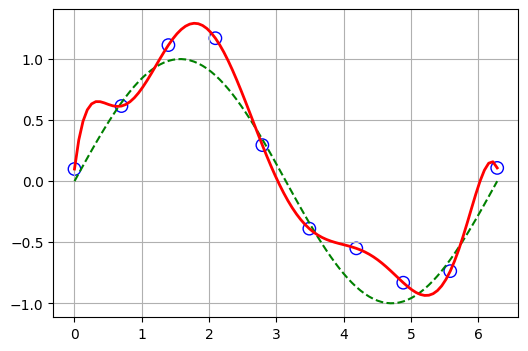

In [46]:
plt.figure(figsize=(6, 4))
plt.scatter(x, y, facecolor="none", edgecolor="blue", s=80, label='Dados de Treino (Ruidosos)')
plt.plot(x_v, y_v, color='green', linestyle='--', label='Função Real $sin(x)$')
plt.plot(x_v, yp, color='red', linewidth=2, label=f'Ajuste Polinomial (M={M})')
plt.grid()

In [48]:
# Ajustando os limites do gráfico para melhor visualização:

print(f"Intercepto (w0): {model.intercept_:.4f}")
print(f"Coeficientes (w1 a wM): {model.coef_}")


Intercepto (w0): 0.0993
Coeficientes (w1 a wM): [ 0.00000000e+00  4.50520930e+00 -1.32240528e+01  1.74150503e+01
 -1.12776808e+01  3.92430171e+00 -7.58280630e-01  7.81181148e-02
 -3.60100894e-03  3.43654000e-05]
